<a href="https://colab.research.google.com/github/Anmeshlad/Array-Practice-problems-Daily-expense-tracker-project/blob/main/Loan_Default_Risk_Predictor_ML_CP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn import preprocessing

import statsmodels
import statsmodels.api as sm

In [ ]:
finance_df = pd.read_csv('/content/drive/MyDrive/Synthetic_Financial_Risk_Classification_Dataset.csv')
finance_df

,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
0,56,54224.45,19,34,788.5,6526.24,48,8.48,0.386,2471.25,...,2,0.929,3,19,22,4.57,0.108,1,87,0
1,46,31979.97,20,14,597.5,24206.88,12,17.32,0.554,1497.90,...,1,0.748,5,32,7,4.39,0.284,0,69,0
2,32,90205.48,11,8,644.8,21991.75,24,13.83,0.266,3260.17,...,1,0.889,3,98,70,5.36,0.863,2,87,0
3,60,68433.75,15,22,655.9,49169.59,60,15.35,0.679,2738.57,...,3,0.978,2,80,56,10.04,0.056,1,52,1
4,25,71467.17,19,5,717.3,18521.41,12,14.04,0.348,3035.41,...,2,0.384,3,9,33,6.16,0.896,0,86,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,66968.35,20,8,642.6,8080.59,36,15.61,0.469,2947.39,...,1,0.468,1,47,98,1.54,0.253,0,10,0
9996,47,70876.50,18,18,762.0,20483.53,24,11.21,0.135,2978.89,...,2,0.310,2,96,3,8.81,0.639,2,64,0
9997,56,64556.37,17,4,699.4,49799.22,12,13.56,0.365,2597.67,...,2,0.699,1,15,76,3.41,0.582,1,56,0
9998,24,48003.54,9,4,770.2,22541.45,48,12.74,0.398,2138.31,...,3,0.544,3,38,77,4.30,0.961,0,5,0


In [ ]:
finance_df.shape

(10000, 25)

In [ ]:
print("Number of duplicate rows:", finance_df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
finance_df.columns

Index(['age', 'annual_income', 'education_years', 'work_experience_years',
       'credit_score', 'loan_amount', 'loan_duration_months', 'interest_rate',
       'debt_to_income_ratio', 'monthly_expenses', 'savings_balance',
       'investment_balance', 'number_of_dependents',
       'employment_stability_years', 'housing_status_score',
       'marital_status_score', 'health_risk_index', 'insurance_coverage_score',
       'spending_score', 'online_activity_score', 'device_usage_hours',
       'location_risk_index', 'previous_default_count',
       'financial_literacy_score', 'loan_default'],
      dtype='object')

In [ ]:
finance_df.describe()

,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.557600,59877.147342,14.107400,12.382000,679.413990,27674.561401,35.998800,15.102176,0.501301,2496.101170,...,2.006100,0.502251,3.008700,50.258800,50.946600,6.468874,0.495447,0.376700,50.584100,0.154600
std,13.749581,15167.957173,3.733425,10.830642,69.853142,12916.429200,16.965895,2.335822,0.229898,542.301099,...,0.817147,0.288089,1.418882,28.807051,28.914795,3.166589,0.289731,0.742464,28.925598,0.361541
min,18.000000,15000.000000,8.000000,0.000000,450.000000,5005.800000,12.000000,7.250000,0.100000,554.310000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,49545.102500,11.000000,3.000000,632.600000,16602.887500,24.000000,13.540000,0.304000,2131.220000,...,1.000000,0.251000,2.000000,26.000000,26.000000,3.730000,0.244000,0.000000,26.000000,0.000000
50%,41.500000,60009.620000,14.000000,9.000000,679.450000,27693.110000,36.000000,15.100000,0.500000,2500.460000,...,2.000000,0.501000,3.000000,50.000000,51.000000,6.470000,0.491000,0.000000,51.000000,0.000000
75%,53.000000,70234.877500,17.000000,19.000000,726.800000,38838.725000,48.000000,16.670000,0.699000,2854.685000,...,3.000000,0.749250,4.000000,75.000000,76.000000,9.190000,0.748000,0.000000,76.000000,0.000000
max,65.000000,113160.980000,20.000000,48.000000,850.000000,49993.770000,60.000000,23.330000,0.900000,4557.170000,...,3.000000,1.000000,5.000000,100.000000,100.000000,12.000000,1.000000,3.000000,100.000000,1.000000


In [ ]:
finance_df.dtypes

,0
age,int64
annual_income,float64
education_years,int64
work_experience_years,int64
credit_score,float64
loan_amount,float64
loan_duration_months,int64
interest_rate,float64
debt_to_income_ratio,float64
monthly_expenses,float64


In [ ]:
finance_df.nunique()

,0
age,48
annual_income,9963
education_years,13
work_experience_years,49
credit_score,2828
loan_amount,9992
loan_duration_months,5
interest_rate,1179
debt_to_income_ratio,801
monthly_expenses,9727


In [ ]:
finance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         10000 non-null  int64  
 1   annual_income               10000 non-null  float64
 2   education_years             10000 non-null  int64  
 3   work_experience_years       10000 non-null  int64  
 4   credit_score                10000 non-null  float64
 5   loan_amount                 10000 non-null  float64
 6   loan_duration_months        10000 non-null  int64  
 7   interest_rate               10000 non-null  float64
 8   debt_to_income_ratio        10000 non-null  float64
 9   monthly_expenses            10000 non-null  float64
 10  savings_balance             10000 non-null  float64
 11  investment_balance          10000 non-null  float64
 12  number_of_dependents        10000 non-null  int64  
 13  employment_stability_years  1000

In [ ]:
finance_df.isnull().sum()

,0
age,0
annual_income,0
education_years,0
work_experience_years,0
credit_score,0
loan_amount,0
loan_duration_months,0
interest_rate,0
debt_to_income_ratio,0
monthly_expenses,0



Visualizing distributions of numerical features...


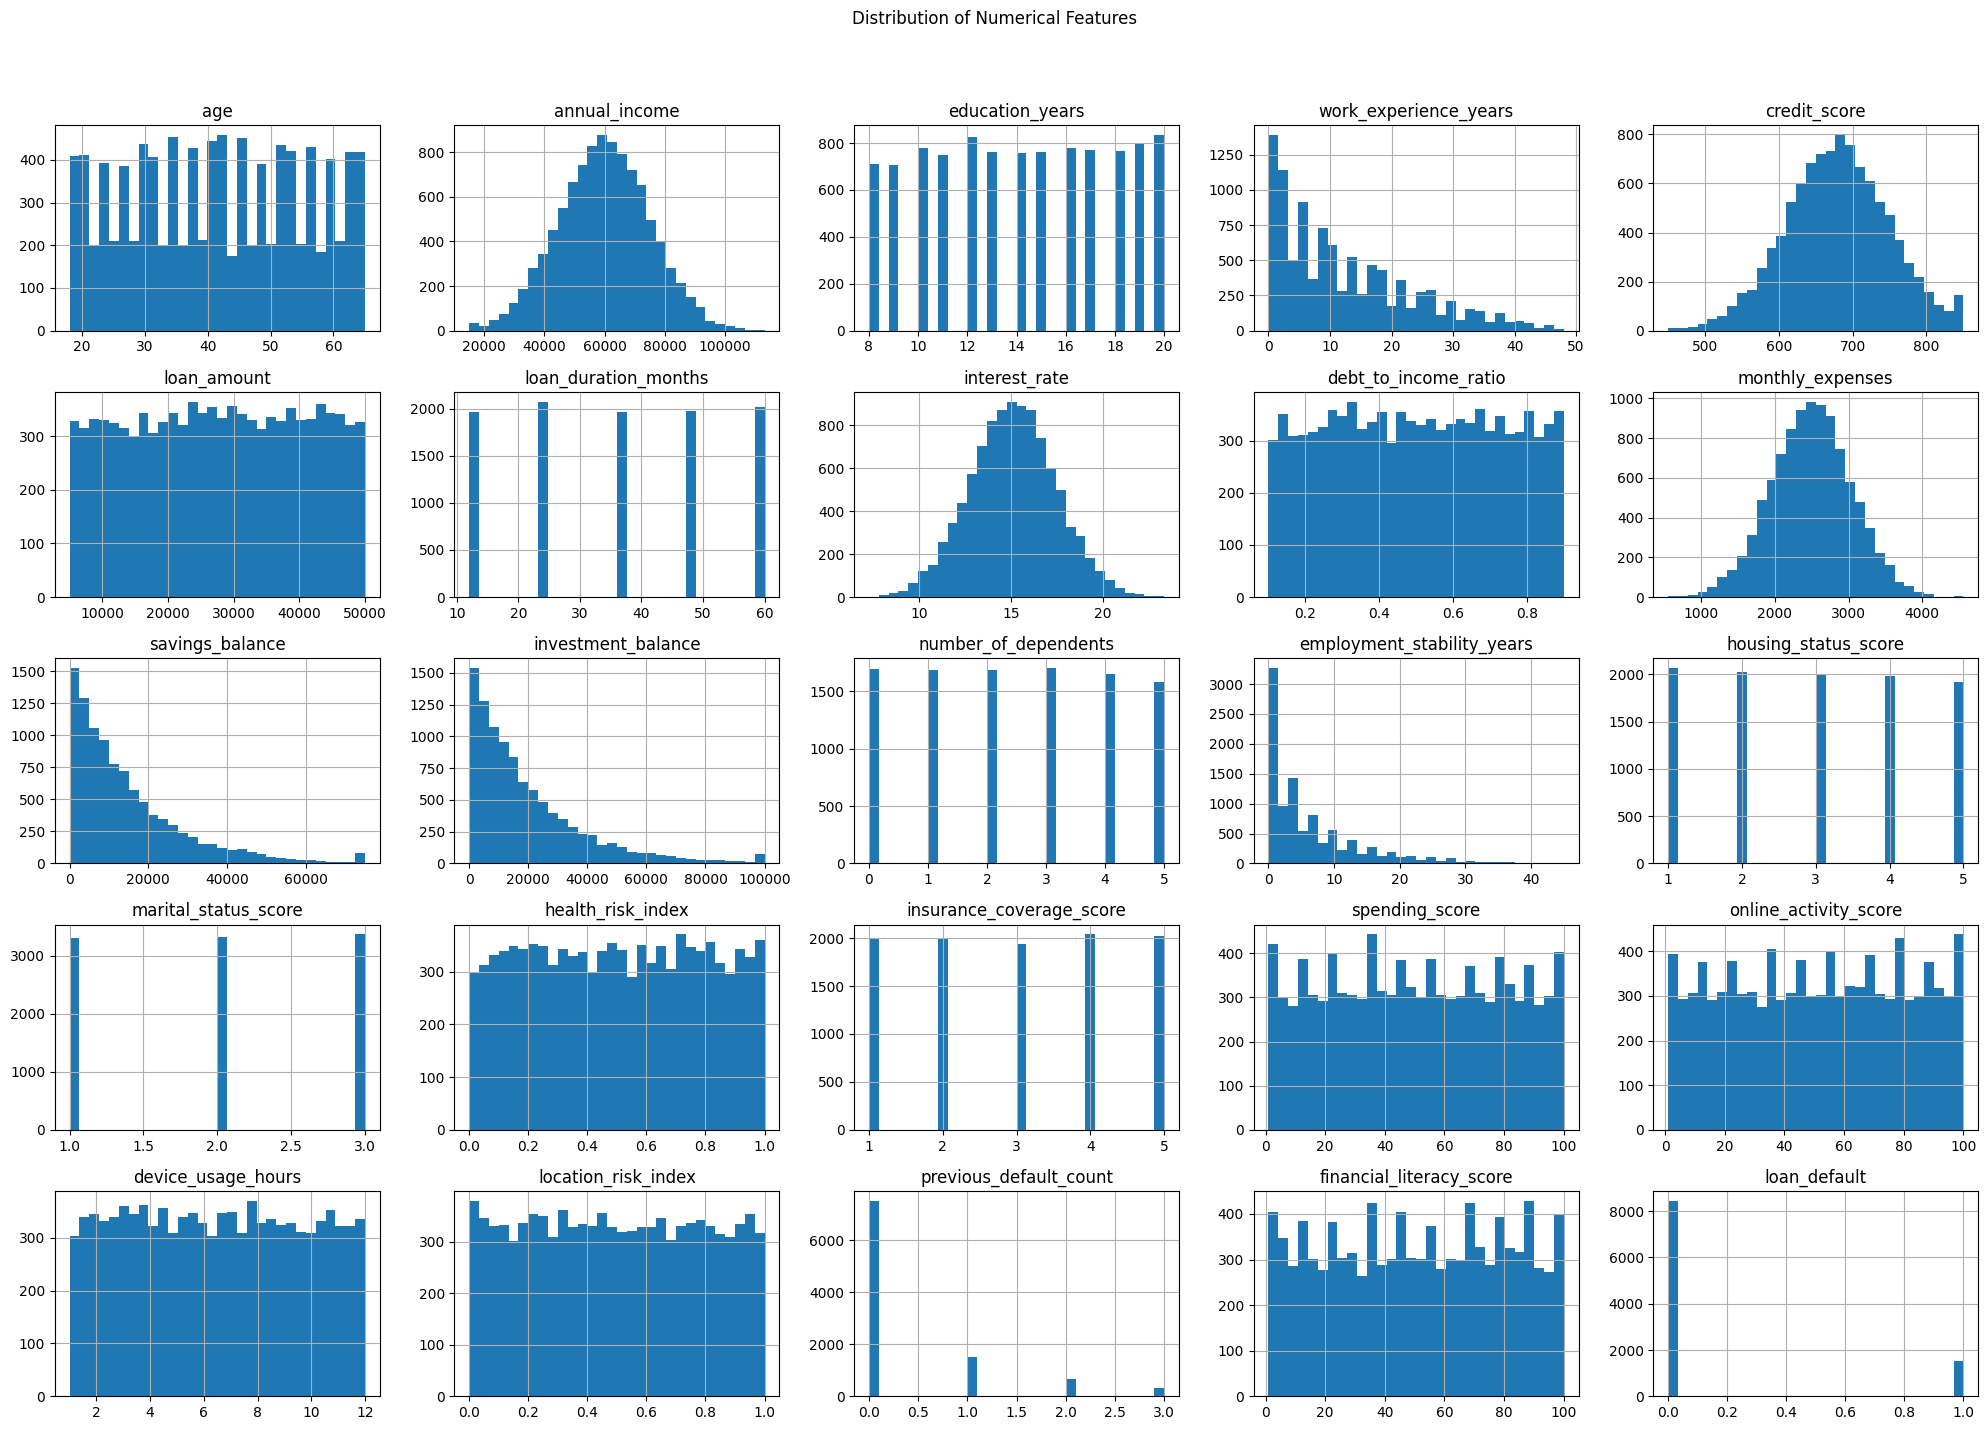

In [ ]:
print("\nVisualizing distributions of numerical features...")
finance_df.hist(bins=30, figsize=(20, 15))
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

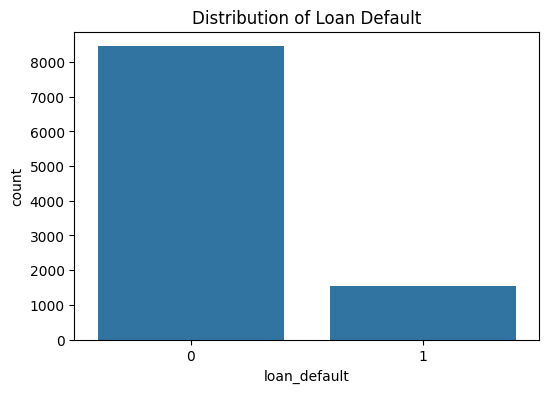

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_default', data=finance_df)
plt.title('Distribution of Loan Default')
plt.show()


Displaying Correlation Matrix Heatmap...


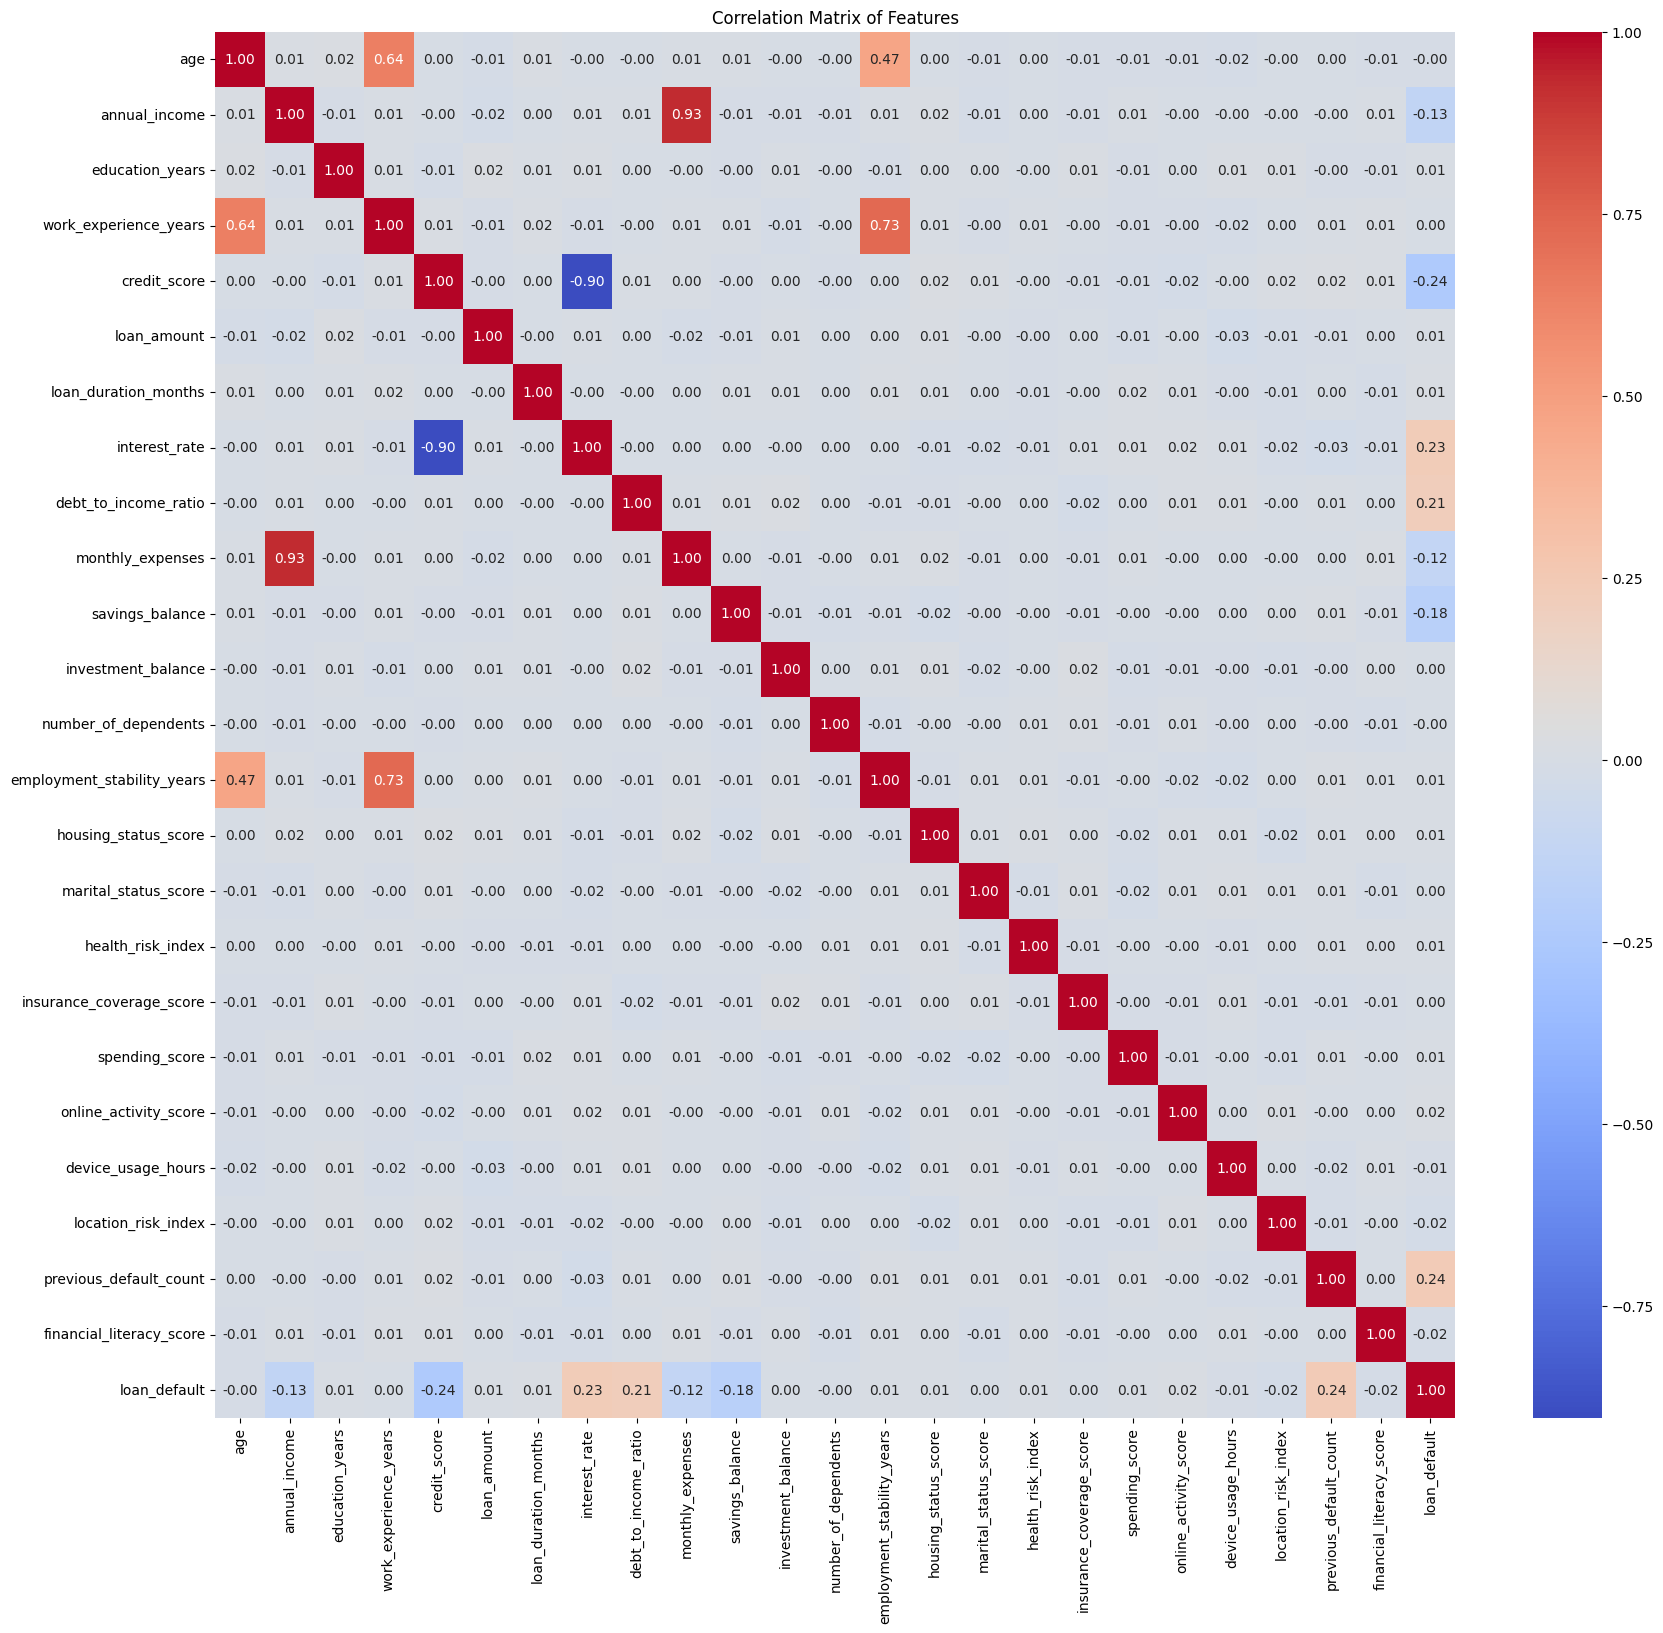

In [ ]:
print("\nDisplaying Correlation Matrix Heatmap...")
plt.figure(figsize=(20, 18))
sns.heatmap(finance_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
finance_df.isnull().sum()

,0
age,0
annual_income,0
education_years,0
work_experience_years,0
credit_score,0
loan_amount,0
loan_duration_months,0
interest_rate,0
debt_to_income_ratio,0
monthly_expenses,0


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

X = finance_df.drop('loan_default', axis=1)
y = finance_df['loan_default']

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)
print("\nDistribution of 'loan_default' after SMOTE:")
print(y_resampled.value_counts())

fianance_df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)
print(fianance_df_upsampled.head())

Shape of X_resampled: (16908, 24)
Shape of y_resampled: (16908,)

Distribution of 'loan_default' after SMOTE:
loan_default
0    8454
1    8454
Name: count, dtype: int64
   age  annual_income  education_years  work_experience_years  credit_score  \
0   56       54224.45               19                     34         788.5   
1   46       31979.97               20                     14         597.5   
2   32       90205.48               11                      8         644.8   
3   60       68433.75               15                     22         655.9   
4   25       71467.17               19                      5         717.3   

   loan_amount  loan_duration_months  interest_rate  debt_to_income_ratio  \
0      6526.24                    48           8.48                 0.386   
1     24206.88                    12          17.32                 0.554   
2     21991.75                    24          13.83                 0.266   
3     49169.59                    60          15

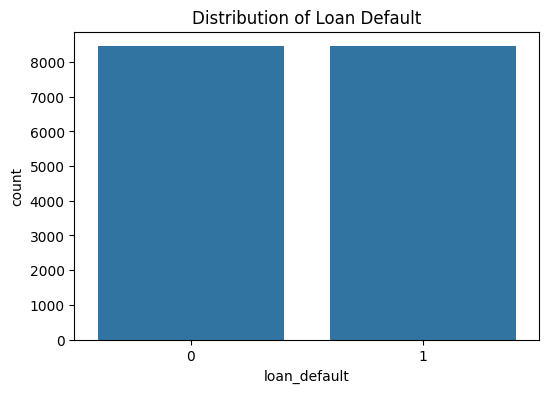

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_default', data=fianance_df_upsampled)
plt.title('After sampling Distribution of Loan Default')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (13526, 24)
Shape of X_test: (3382, 24)
Shape of y_train: (13526,)
Shape of y_test: (3382,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_upsampled = scaler.fit_transform(X_train)
X_test_scaled_upsampled = scaler.transform(X_test)

print("\nX_train_scaled_upsampled:")
print(X_train_scaled_upsampled)
print("\nX_test_scaled_upsampled:")
print(X_test_scaled_upsampled)


X_train_scaled_upsampled:
[[-0.48800559  1.28075464  0.59410434 ... -0.38819617 -0.5675822
   0.04281556]
 [ 0.0560924   0.94025478 -0.84942791 ... -0.0573367  -0.5675822
  -1.1153563 ]
 [-1.42074499 -1.47245399  0.01669144 ...  0.03560136 -0.5675822
  -1.37687898]
 ...
 [-0.87664701  0.10048299  0.59410434 ...  0.79769341 -0.5675822
  -0.96591477]
 [-0.17709245 -0.88235048  0.30539789 ...  1.314429    3.51237359
  -0.4802298 ]
 [-0.48800559 -0.94841711  0.59410434 ...  0.27684789 -0.5675822
  -1.63840166]]

X_test_scaled_upsampled:
[[-1.03210358 -0.28194862  0.8828108  ... -0.11491902 -0.5675822
   0.22961748]
 [-0.4102773  -0.33509398 -1.42684082 ...  0.05047145 -0.5675822
  -0.14398635]
 [ 0.60019039  0.42632234  1.17151725 ...  0.40363606  0.79240307
   0.67794207]
 ...
 [-0.17709245 -1.60312015  1.17151725 ...  1.19918581 -0.5675822
  -1.71312242]
 [ 1.06656009 -1.08849067  0.30539789 ... -0.29073108 -0.5675822
  -1.04063554]
 [-0.33254902  0.47416101  0.01669144 ...  1.53748033 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)

print("\nTraining Logistic Regression model...")
log_reg_model.fit(X_train_scaled_upsampled, y_train)

y_pred_log_reg = log_reg_model.predict(X_test_scaled_upsampled)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_scaled_upsampled)[:, 1]

print("\nLogistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))


Training Logistic Regression model...

Logistic Regression Model Performance:
Accuracy: 0.7876995860437611
ROC-AUC Score: 0.8668821370031834

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78      1691
           1       0.77      0.81      0.79      1691

    accuracy                           0.79      3382
   macro avg       0.79      0.79      0.79      3382
weighted avg       0.79      0.79      0.79      3382



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

print("\nTraining Random Forest model...")
rf_model.fit(X_train_scaled_upsampled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled_upsampled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled_upsampled)[:, 1]

print("\nRandom Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Training Random Forest model...

Random Forest Model Performance:
Accuracy: 0.8962152572442342
ROC-AUC Score: 0.9627860790122403

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1691
           1       0.89      0.91      0.90      1691

    accuracy                           0.90      3382
   macro avg       0.90      0.90      0.90      3382
weighted avg       0.90      0.90      0.90      3382



In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train_scaled_upsampled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled_upsampled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled_upsampled)[:, 1]

print("\nXGBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:15:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Performance:
Accuracy: 0.9009461856889415
ROC-AUC Score: 0.9678861303851993

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      1691
           1       0.90      0.91      0.90      1691

    accuracy                           0.90      3382
   macro avg       0.90      0.90      0.90      3382
weighted avg       0.90      0.90      0.90      3382

